In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from pytorch_msssim import ms_ssim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from sklearn.model_selection import KFold

In [3]:
K_COL = '/Volumes/easystore/proton-deuteron/col&ind/kaonscol.pkl'
K_IND = '/Volumes/easystore/proton-deuteron/col&ind/kaonsind.pkl'

k_col = pd.read_pickle(K_COL)
k_ind = pd.read_pickle(K_IND)

P_COL = '/Volumes/easystore/proton-deuteron/col&ind/pickyprotonscol.pkl'
P_IND = '/Volumes/easystore/proton-deuteron/col&ind/pickyprotonsind.pkl'

p_col = pd.read_pickle(P_COL)
p_ind = pd.read_pickle(P_IND)

masses = pd.read_csv('/Volumes/easystore/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. e.g. mass, if no. of particles = 1

col = pd.concat([k_col, p_col], ignore_index=True)
ind = pd.concat([k_ind, p_ind], ignore_index=True)

col = pd.merge(
    col,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

ind = pd.merge(
    ind,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

print(ind.shape, col.shape)

(10940, 38) (10940, 38)


In [4]:
k_col

,run,subrun,event,cluster_idx_ind,cluster_idx_col,d_min_c,d_max_c,d_min_r,d_max_r,d_h,...,bbox_min_col,bbox_max_row,bbox_max_col,width,height,aspect_ratio,compactness,image_intensity,matrix_transformed,column_maxes
0,8557,44,2258,0,0,-3,56,16,22,6,...,154,120,1108,954,88,10.840909,0.060928,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[140, 105, 82, 93, 81, 100, 209, 99, 113, 88, ..."
1,8557,52,2623,10,0,-3,54,-3,-10,-7,...,155,97,854,699,75,9.320000,0.084635,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[49, 83, 99, 93, 131, 131, 132, 113, 130, 213,..."
2,8557,52,2623,6,1,-340,227,10,54,44,...,1125,76,1755,630,46,13.695652,0.082195,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 16, 16, 17,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[31, 85, 84, 124, 103, 112, 111, 93, 126, 77, ..."
3,8557,71,3486,1,2,-3,125,7,-14,-21,...,150,84,1067,917,57,16.087719,0.075666,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[66, 179, 277, 245, 212, 161, 234, 197, 196, 2..."
4,8557,73,3571,0,1,29,44,-5,5,10,...,1660,161,1835,175,140,1.250000,0.350857,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[21, 82, 83, 101, 95, 126, 126, 133, 131, 133,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,9788,247,21771,0,0,-1016,46,12,30,18,...,147,110,1345,1198,81,14.790123,0.075136,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[20, 38, 82, 69, 71, 62, 58, 76, 58, 60, 71, 6..."
1650,9788,258,22704,2,2,591,631,-3,-3,0,...,1495,27,1560,65,2,32.500000,0.576923,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0], [17, 0], [17, 0], [18, 0], [19, 0], ...","[23, 60]"
1651,9788,267,23425,2,1,11,51,-14,-25,-11,...,746,171,1117,371,155,2.393548,0.129867,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[24, 50, 50, 47, 41, 43, 59, 59, 49, 65, 48, 5..."
1652,9788,276,24241,0,1,-2,47,-8,-6,2,...,144,161,842,698,142,4.915493,0.075911,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[42, 49, 114, 72, 52, 80, 157, 69, 86, 63, 98,..."


In [5]:
col[col['particle_type'] == 'kaon']

,run,subrun,event,cluster_idx_ind,cluster_idx_col,d_min_c,d_max_c,d_min_r,d_max_r,d_h,...,width,height,aspect_ratio,compactness,image_intensity,matrix_transformed,column_maxes,p,m,beamline_mass
0,8557,44,2258,0,0,-3,56,16,22,6,...,954,88,10.840909,0.060928,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[140, 105, 82, 93, 81, 100, 209, 99, 113, 88, ...",1.0,0.0,371.84
1,8557,52,2623,10,0,-3,54,-3,-10,-7,...,699,75,9.320000,0.084635,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[49, 83, 99, 93, 131, 131, 132, 113, 130, 213,...",1.0,0.0,432.90
2,8557,52,2623,6,1,-340,227,10,54,44,...,630,46,13.695652,0.082195,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 16, 16, 17,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[31, 85, 84, 124, 103, 112, 111, 93, 126, 77, ...",1.0,0.0,432.90
3,8557,71,3486,1,2,-3,125,7,-14,-21,...,917,57,16.087719,0.075666,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[66, 179, 277, 245, 212, 161, 234, 197, 196, 2...",1.0,0.0,510.72
4,8557,73,3571,0,1,29,44,-5,5,10,...,175,140,1.250000,0.350857,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[21, 82, 83, 101, 95, 126, 126, 133, 131, 133,...",1.0,0.0,644.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,9788,247,21771,0,0,-1016,46,12,30,18,...,1198,81,14.790123,0.075136,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[20, 38, 82, 69, 71, 62, 58, 76, 58, 60, 71, 6...",1.0,1.0,512.97
1650,9788,258,22704,2,2,591,631,-3,-3,0,...,65,2,32.500000,0.576923,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0], [17, 0], [17, 0], [18, 0], [19, 0], ...","[23, 60]",1.0,0.0,599.11
1651,9788,267,23425,2,1,11,51,-14,-25,-11,...,371,155,2.393548,0.129867,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[24, 50, 50, 47, 41, 43, 59, 59, 49, 65, 48, 5...",1.0,0.0,503.72
1652,9788,276,24241,0,1,-2,47,-8,-6,2,...,698,142,4.915493,0.075911,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[42, 49, 114, 72, 52, 80, 157, 69, 86, 63, 98,...",1.0,1.0,541.98


In [6]:
maxes = col['column_maxes'].values                                                  # max ADC for each wire hit

normalised = []                               

for i, signal in enumerate(maxes):                                                  # normalise 0-1 per cluster using max
    
    minimum = 0
    maximum = np.max(signal)

    if maximum > minimum:
        normalised_signal = (signal - minimum) / (maximum - minimum)
    else:
        normalised_signal = np.zeros_like(signal, dtype=float)
        print(f'Error: Max not greater than min in signal {i}.')

    normalised.append(normalised_signal)

adcdiff = [np.diff(signal) for signal in normalised]                                # difference between consecutive hits
maxdiff = [np.max(diff) for diff in adcdiff]; col['maxdiff'] = maxdiff              # max ADC difference

maxes = ind['column_maxes'].values                                                  # for induction plane

normalised = []

for i, signal in enumerate(maxes):
    
    minimum = 0
    maximum = np.max(signal)

    if maximum > minimum:
        normalised_signal = (signal - minimum) / (maximum - minimum)
    else:
        normalised_signal = np.zeros_like(signal, dtype=float)
        print(f'Error: Max not greater than min in signal {i}.')

    normalised.append(normalised_signal)

adcdiff = [np.diff(signal) for signal in normalised]
maxdiff = [np.max(diff) for diff in adcdiff]; ind['maxdiff'] = maxdiff

In [83]:
removed_indices_col = col[~(col['maxdiff'] >= 0)].index
removed_indices_ind = ind[~(ind['maxdiff'] >= 0)].index

removed_indices = removed_indices_col.union(removed_indices_ind)

col = col[~col.index.isin(removed_indices)]; print(col.shape)
ind = ind[~ind.index.isin(removed_indices)]; print(ind.shape)

KeyError: 'maxdiff'

In [7]:
removed_indices_col = col[~((col['height'] > 5) & (col['height'] < 179) & (col['width'] < 1500))].index            # remove long and wide images
removed_indices_ind = ind[~((ind['height'] > 5) & (ind['height'] < 179) & (ind['width'] < 1500))].index


removed_indices = removed_indices_col.union(removed_indices_ind)

col = col[~col.index.isin(removed_indices)]; print(col.shape)
ind = ind[~ind.index.isin(removed_indices)]; print(ind.shape)

(9641, 39)
(9641, 39)


In [8]:
def pad_image(image, target_wh=(1502, 179)):
    """
    Place a 2D image block in the centre of a zero canvas.

    image: 2D np.ndarray, shape (h, w)
    target_wh: (target_width, target_height)
    """
    target_w, target_h = target_wh
    canvas = np.zeros((target_h, target_w), dtype=image.dtype)

    h, w = image.shape
    
    v = int(np.argmax(image[0]))

    a = 751 - v
    
    # Compute top-left corner so image is centred, clamped to fit within canvas
    y0 = 0
    x0 = max(0, min(a, target_w - w))  # Clamp to valid range [0, target_w - w]
    y1 = y0 + h
    x1 = x0 + w

    # Place the image block
    canvas[y0:y1, x0:x1] = image

    return canvas

def downsample_image(image, target_shape=(512, 40)):
    '''
    Reduce an image from original to target shape.
    '''
    scale_y = target_shape[1] / image.shape[0]
    scale_x = target_shape[0] / image.shape[1]
    return zoom(image, (scale_y, scale_x), order=1)  # order=1 for bilinear interpolation


In [9]:
# making the images for the CAE model

p_c = []
p_i = []

k_c = []
k_i = []

for idx, row in col[col['particle_type'] == 'proton'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    p_c.append(padded)

for idx, row in ind[ind['particle_type'] == 'proton'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    p_i.append(padded)

for idx, row in col[col['particle_type'] == 'kaon'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    k_c.append(padded)

for idx, row in ind[ind['particle_type'] == 'kaon'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    k_i.append(padded)

p_c = np.array(p_c)
p_i = np.array(p_i)

k_c = np.array(k_c)
k_i = np.array(k_i)

p_c_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p_c])
p_i_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p_i])

k_c_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in k_c])
k_i_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in k_i])

In [10]:
p_i_d.shape, p_c_d.shape, k_i_d.shape, k_c_d.shape

((8374, 64, 64), (8374, 64, 64), (1267, 64, 64), (1267, 64, 64))

In [1]:
protimages = np.stack([p_c, p_i], axis=1)
kaonimages = np.stack([k_c, k_i], axis=1)       

NameError: name 'np' is not defined

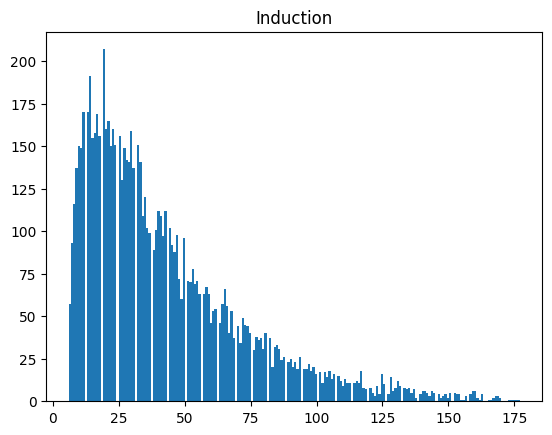

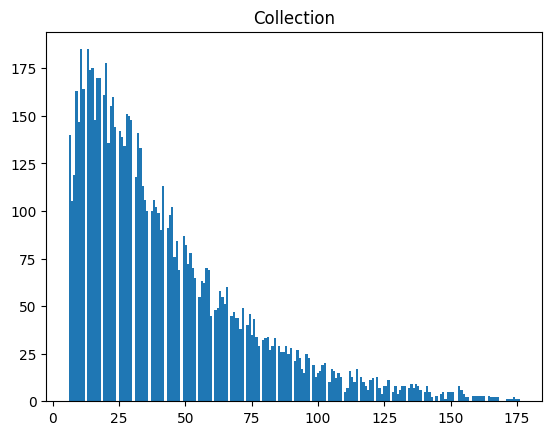

In [11]:
plt.hist(col[col['particle_type'] == 'proton']['height'], bins=max(p_col['height'])); plt.title('Induction'); plt.show()
plt.hist(ind[col['particle_type'] == 'proton']['height'], bins=max(p_ind['height'])); plt.title('Collection'); plt.show()

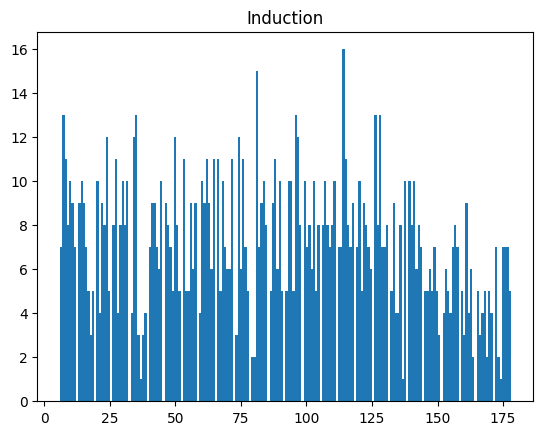

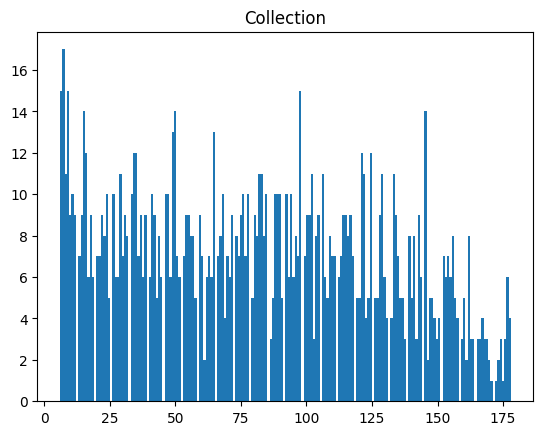

In [12]:
plt.hist(col[col['particle_type'] == 'kaon']['height'], bins=max(p_col['height'])); plt.title('Induction'); plt.show()
plt.hist(ind[col['particle_type'] == 'kaon']['height'], bins=max(p_ind['height'])); plt.title('Collection'); plt.show()

<Axes: >

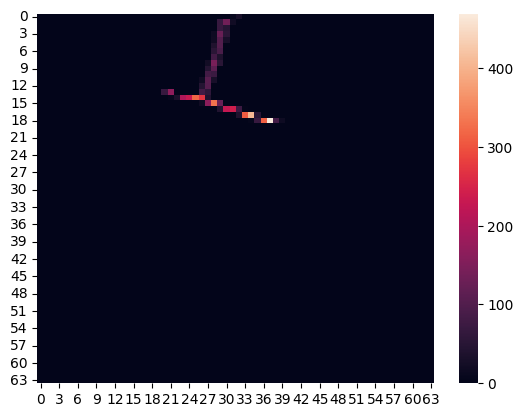

In [21]:
sns.heatmap(k[300, 0])

In [22]:
p = np.stack([p_c_d, p_i_d], axis=1)            # shape: (N, 2, H, W)
k = np.stack([k_c_d, k_i_d], axis=1)            # shape: (N, 2, H, W)

p = torch.from_numpy(p).float()
k = torch.from_numpy(k).float()

In [23]:
class CAE(nn.Module):
    def __init__(self, input_hw=(240, 240), latent=8, p_enc=0.2):
        super(CAE, self).__init__()
        in_h, in_w = input_hw
        assert in_h % 16 == 0 and in_w % 16 == 0, "input spatial dims must be divisible by 16"

        self.encoder = nn.Sequential(
            nn.Conv2d(2, 32, 5, stride=2, padding=2), nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout2d(p_enc),
            nn.Conv2d(32, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout2d(p_enc),
            nn.Conv2d(64, 128, 5, stride=2, padding=2), nn.BatchNorm2d(128), nn.ReLU(), nn.Dropout2d(p_enc),
            nn.Conv2d(128, 256, 5, stride=2, padding=2), nn.BatchNorm2d(256), nn.ReLU(), nn.Dropout2d(p_enc)
        )

        self.h_enc = in_h // 16
        self.w_enc = in_w // 16
        flat_size = 256 * self.h_enc * self.w_enc

        self.fc_enc = nn.Linear(flat_size, latent)
        self.fc_dec = nn.Linear(latent, flat_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 2, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU()  
        )

    def forward(self, x):
        enc = self.encoder(x)            # (B,256,H_enc,W_enc)
        z = enc.view(enc.size(0), -1)    # (B, flat_size)
        z = self.fc_enc(z)               # (B, latent)
        z = self.fc_dec(z)               # (B, flat_size)
        y = z.view(x.size(0), 256, self.h_enc, self.w_enc)  # (B,256,H_enc,W_enc)
        y = self.decoder(y)              # (B,H,W)
        return y

In [24]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Training device:", device)

X = torch.tensor(p, dtype=torch.float32)  # shape (N, 2, H, W)
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

epochs = 100
batch_size = 32

fold_train_losses, fold_val_losses = [], []
fold_REs = []
fold_REs_k = []

Training device: mps


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_2574/3068461980.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(p, dtype=torch.float32)  # shape (N, 2, H, W)


Training device: mps
===== Training (80/20 split) =====
Epoch 10/100: Train=21.0834447543, Val=21.9950045100
Epoch 20/100: Train=16.0210183689, Val=19.4576536574
Epoch 30/100: Train=13.5111166137, Val=17.1067462597
Epoch 40/100: Train=11.7727723349, Val=16.5373638981
Epoch 50/100: Train=10.7614677066, Val=16.4366259305
Epoch 60/100: Train=10.0634942032, Val=16.0458710598
Epoch 70/100: Train=9.1460189501, Val=16.4220164767
Epoch 80/100: Train=8.6607845579, Val=16.4514032580
Epoch 90/100: Train=8.1478881064, Val=15.9859925486
Epoch 100/100: Train=7.9512732915, Val=16.0996718317

Model saved as model_80_20.pt
Model loaded successfully

Computing validation REs...


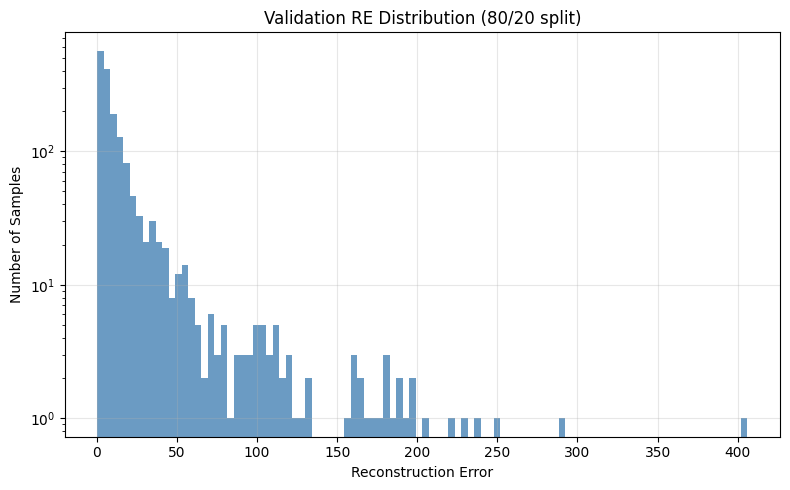

Computing RE on kaon dataset...


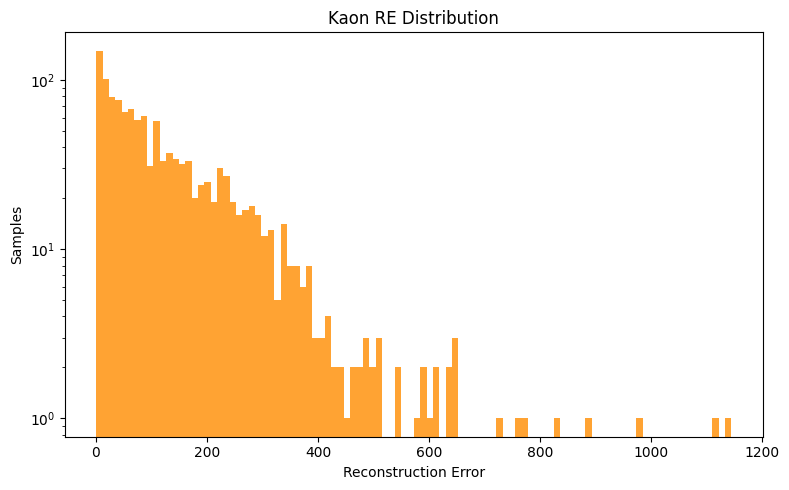

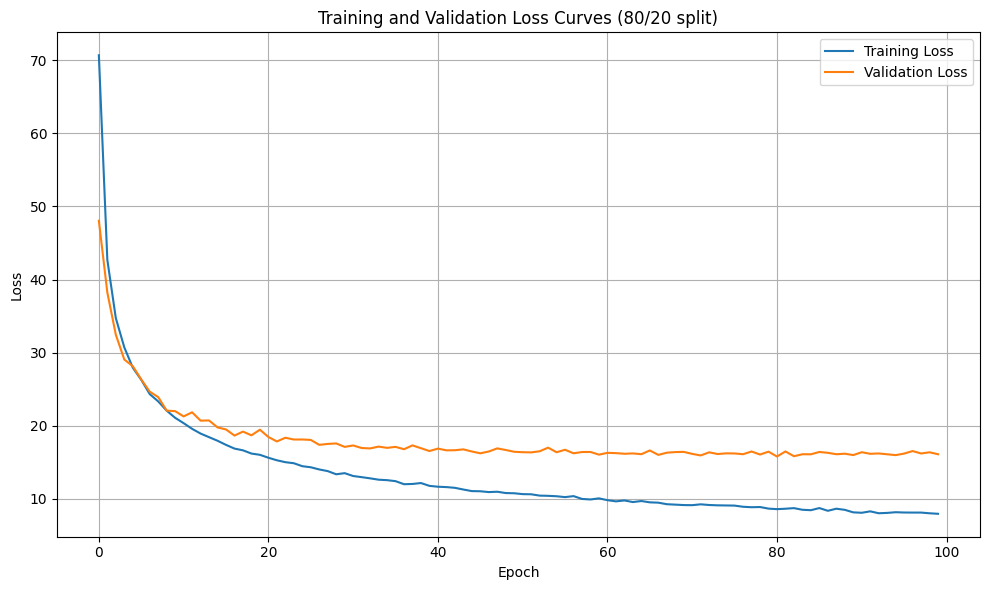

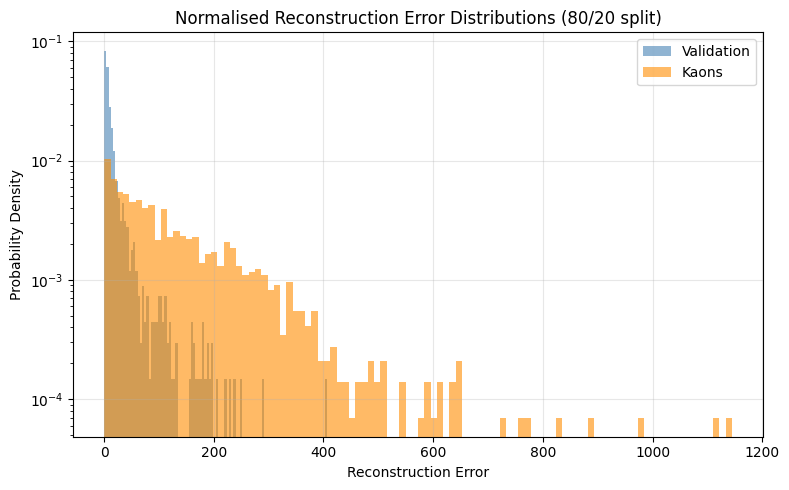

Validation mean RE: 16.1198673248 ± 30.3840599060
Kaons mean RE: 129.5153045654 ± 133.9976654053


In [25]:
# 80/20 split training (alternative to k-fold)
from sklearn.model_selection import train_test_split

# Split indices
all_indices = np.arange(len(p))
train_idx, val_idx = train_test_split(all_indices, test_size=0.2, random_state=42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Training device:", device)

train_subset = Subset(p, train_idx)
val_subset = Subset(p, val_idx)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

# Initialize model, optimizer, loss
model = CAE(input_hw=(64, 64), latent=8).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

train_losses = []
val_losses = []

# Training
print("===== Training (80/20 split) =====")
for epoch in range(epochs):
    model.train()
    total_train = 0.0

    for xb in train_loader:
        xb = xb.to(device)
        optim.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, xb)
        loss.backward()
        optim.step()
        total_train += loss.item()

    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for xb in val_loader:
            xb = xb.to(device)
            preds = model(xb)
            loss = loss_fn(preds, xb)
            total_val += loss.item()

    train_losses.append(total_train / len(train_loader))
    val_losses.append(total_val / len(val_loader))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train={train_losses[-1]:.10f}, Val={val_losses[-1]:.10f}")

# Save model
torch.save(model.state_dict(), "model_80_20.pt")
print("\nModel saved as model_80_20.pt")

# Load model (verify save/load works)
loaded_model = CAE(input_hw=(64, 64), latent=8).to(device)
loaded_model.load_state_dict(torch.load("model_80_20.pt"))
loaded_model.eval()
print("Model loaded successfully")
model = loaded_model

# ===== Inference on validation set =====
print("\nComputing validation REs...")

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device_inf)

X_val_np = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()
N, C, H, W = X_val_np.shape
recon_all = np.empty((N, C, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, 8):
        j = min(i + 8, N)
        xb = torch.tensor(X_val_np[i:j], dtype=torch.float32).to(device_inf)
        out = model(xb)
        recon_all[i:j] = out.cpu().numpy()

        enc = model.encoder(xb)
        z_flat = enc.flatten(1)
        z = model.fc_enc(z_flat)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

mse_per_pixel = (recon_all - X_val_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2, 3))

# Wrap in lists to maintain compatibility with downstream code
fold_train_losses = [train_losses]
fold_val_losses = [val_losses]
fold_REs = [RE_per_sample]

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Validation RE Distribution (80/20 split)")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== Inference on kaon data =====
print("Computing RE on kaon dataset...")

Xk_np = k.cpu().numpy() if torch.is_tensor(k) else np.array(k, dtype=np.float32)
N, C, H, W = Xk_np.shape
recon_all_k = np.empty((N, C, H, W), dtype=np.float32)

latent_vectors_k = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, 8):
        j = min(i + 8, N)
        xb = torch.tensor(Xk_np[i:j], dtype=torch.float32).to(device_inf)
        out = model(xb)
        recon_all_k[i:j] = out.cpu().numpy()

        enc = model.encoder(xb)
        z_flat = enc.flatten(1)
        z = model.fc_enc(z_flat)
        latent_vectors_k[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

RE_k = ((recon_all_k - Xk_np) ** 2).mean(axis=(1, 2, 3))
fold_REs_k = [RE_k]

plt.figure(figsize=(8, 5))
plt.hist(RE_k, bins=100, color='darkorange', alpha=0.8)
plt.yscale('log')
plt.xlabel("Reconstruction Error")
plt.ylabel("Samples")
plt.title("Kaon RE Distribution")
plt.tight_layout()
plt.show()

# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves (80/20 split)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot combined RE distributions
all_RE_val = np.concatenate(fold_REs)
all_RE_k = np.concatenate(fold_REs_k)

plt.figure(figsize=(8, 5))
plt.hist(all_RE_val, bins=100, density=True, alpha=0.6, color='steelblue', label='Validation')
plt.hist(all_RE_k, bins=100, density=True, alpha=0.6, color='darkorange', label='Kaons')
plt.xlabel("Reconstruction Error")
plt.ylabel("Probability Density")
plt.title("Normalised Reconstruction Error Distributions (80/20 split)")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Validation mean RE: {all_RE_val.mean():.10f} ± {all_RE_val.std():.10f}")
print(f"Kaons mean RE: {all_RE_k.mean():.10f} ± {all_RE_k.std():.10f}")



===== Fold 1/5 =====
Epoch 1/100: Train=98.4729160753, Val=65.5445132622
Epoch 2/100: Train=59.3818080865, Val=52.3102294115
Epoch 3/100: Train=48.1485047202, Val=43.5223207107
Epoch 4/100: Train=41.9656149207, Val=39.1825200228
Epoch 5/100: Train=38.0645200211, Val=36.6432145192
Epoch 6/100: Train=35.1063962492, Val=32.7176381625
Epoch 7/100: Train=33.0555084099, Val=32.3666991087
Epoch 8/100: Train=31.6064557011, Val=30.1890798349
Epoch 9/100: Train=29.5472743581, Val=29.7637771460
Epoch 10/100: Train=28.3789548411, Val=27.8689350348
Epoch 11/100: Train=27.2595917044, Val=28.6668635882
Epoch 12/100: Train=26.6889602698, Val=26.9081595494
Epoch 13/100: Train=25.5261335697, Val=25.7361847621
Epoch 14/100: Train=24.8185289253, Val=26.2714312627
Epoch 15/100: Train=24.4007552989, Val=24.9411764695
Epoch 16/100: Train=23.4702287924, Val=25.6684969755
Epoch 17/100: Train=22.9000598991, Val=24.4227411380
Epoch 18/100: Train=22.2247545048, Val=23.7240825983
Epoch 19/100: Train=21.6218767074

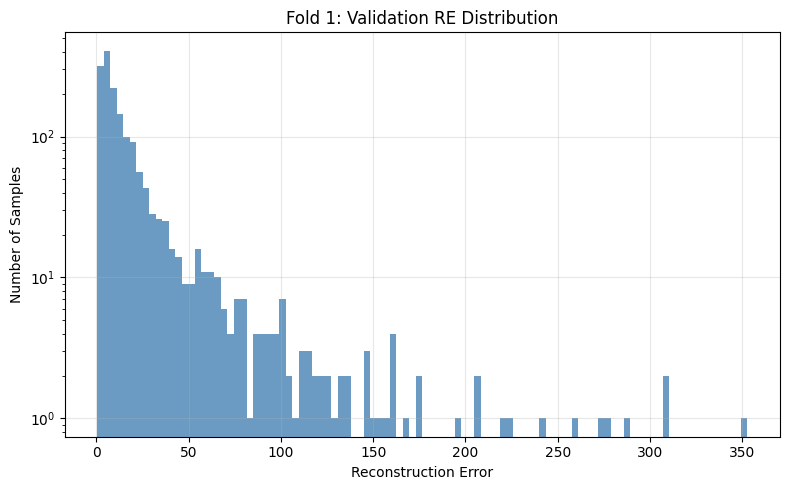

Computing RE on unseen dataset (d)...


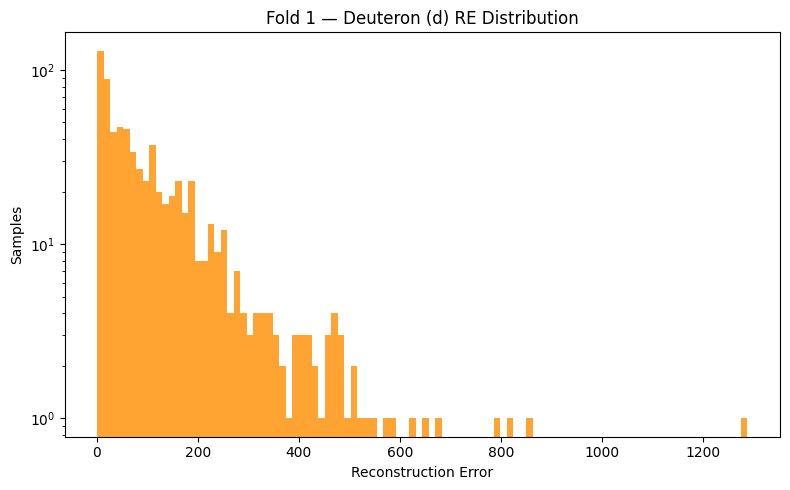


===== Fold 2/5 =====
Epoch 1/100: Train=97.1005270319, Val=64.9726401476
Epoch 2/100: Train=58.0029763712, Val=47.9749092689
Epoch 3/100: Train=47.8227543970, Val=41.5930315164
Epoch 4/100: Train=41.9866428190, Val=37.3728365531
Epoch 5/100: Train=38.6034041284, Val=34.9662929682
Epoch 6/100: Train=35.6371014419, Val=33.8272939279


KeyboardInterrupt: 

In [24]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n===== Fold {fold+1}/{n_splits} =====")

    train_subset = Subset(X, train_idx)
    val_subset = Subset(X, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    model = CAE(input_hw=(64, 64), latent=8).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []

    # --- Training ---
    for epoch in range(epochs):
        model.train()
        total_train, total_val = 0.0, 0.0

        for xb in train_loader:
            xb = xb.to(device)
            optim.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, xb)
            loss.backward()
            optim.step()
            total_train += loss.item()

        model.eval()
        with torch.no_grad():
            for xb in val_loader:
                xb = xb.to(device)
                preds = model(xb)
                loss = loss_fn(preds, xb)
                total_val += loss.item()

        train_losses.append(total_train / len(train_loader))
        val_losses.append(total_val / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train={train_losses[-1]:.10f}, Val={val_losses[-1]:.10f}")

    fold_train_losses.append(train_losses)
    fold_val_losses.append(val_losses)

    # -----------------------------
    # 4. Reconstruction error (RE) on this fold's validation set
    # -----------------------------
    print("Computing validation REs...")

    model.eval()
    device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device_inf)

    X_val_np = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()
    N, C, H, W = X_val_np.shape
    recon_all = np.empty((N, C, H, W), dtype=np.float32)


    latent_dim = model.fc_enc.out_features
    latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(X_val_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all[i:j] = out.cpu().numpy()

            enc = model.encoder(xb)
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    mse_per_pixel = (recon_all - X_val_np) ** 2
    RE_per_sample = mse_per_pixel.mean(axis=(1, 2, 3))
    fold_REs.append(RE_per_sample)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Number of Samples")
    plt.title(f"Fold {fold+1}: Validation RE Distribution")
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # === Compute Reconstruction Error on Unseen Data (k) ======
    # ============================================================

    print("Computing RE on unseen dataset (d)...")

    Xk_np = k.cpu().numpy() if torch.is_tensor(k) else np.array(k, dtype=np.float32)       # unseen data
    N, C, H, W = Xk_np.shape
    recon_all_k = np.empty((N, C, H, W), dtype=np.float32)

    latent_vectors_k = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(Xk_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all_k[i:j] = out.cpu().numpy()

            enc = model.encoder(xb)
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors_k[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    RE_k = ((recon_all_k - Xk_np) ** 2).mean(axis=(1, 2, 3))
    fold_REs_k.append(RE_k)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_k, bins=100, color='darkorange', alpha=0.8)
    plt.yscale('log')
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Samples")
    plt.title(f"Fold {fold+1} — Deuteron (d) RE Distribution")
    plt.tight_layout()
    plt.show()

    # torch.save(model.state_dict(), f"msefolds/CAE_fold{fold+1}.pt")
    # np.save(f"msefolds/RE_val_fold{fold+1}.npy", RE_per_sample)
    # np.save(f"msefolds/RE_d_d_fold{fold+1}.npy", RE_d_d)
    # np.save(f"msefolds/latent_val_fold{fold+1}.npy", latent_vectors)
    # np.save(f"msefolds/latent_d_d_fold{fold+1}.npy", latent_vectors_d)

    # print(f"Saved model and RE arrays for fold {fold+1}.")


plt.figure(figsize=(10, 6))
plt.plot(torch.tensor(fold_train_losses).mean(dim=0), label='Avg Training Loss')
plt.plot(torch.tensor(fold_val_losses).mean(dim=0), label='Avg Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{n_splits}-Fold CV Average Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

all_REs = np.concatenate(fold_REs)
plt.figure(figsize=(8, 5))
plt.hist(all_REs, bins=100, color='teal', alpha=0.7)
plt.yscale('log')
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title(f"Validation RE Distribution (All {n_splits} folds combined)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

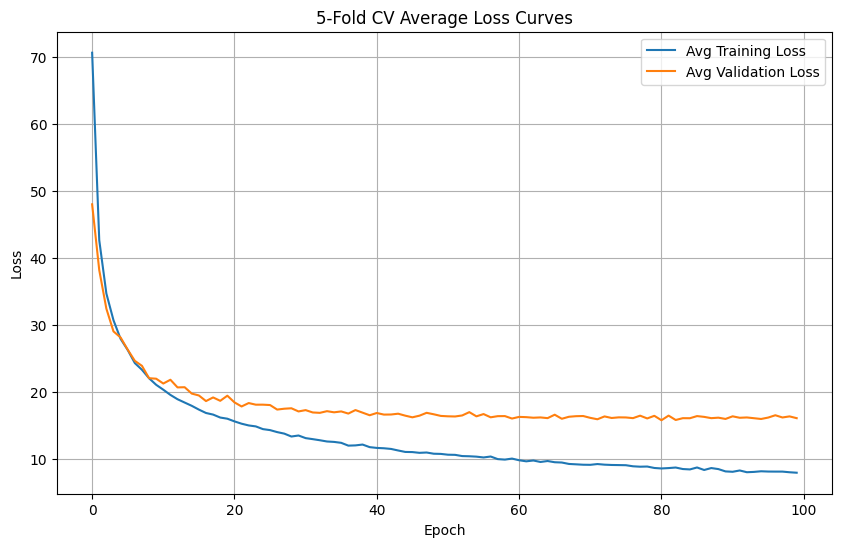

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(torch.tensor(fold_train_losses).mean(dim=0), label='Avg Training Loss')
plt.plot(torch.tensor(fold_val_losses).mean(dim=0), label='Avg Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{n_splits}-Fold CV Average Loss Curves')
plt.legend()
plt.grid(True)
# plt.savefig('Loss.png', dpi=1000)
plt.show()

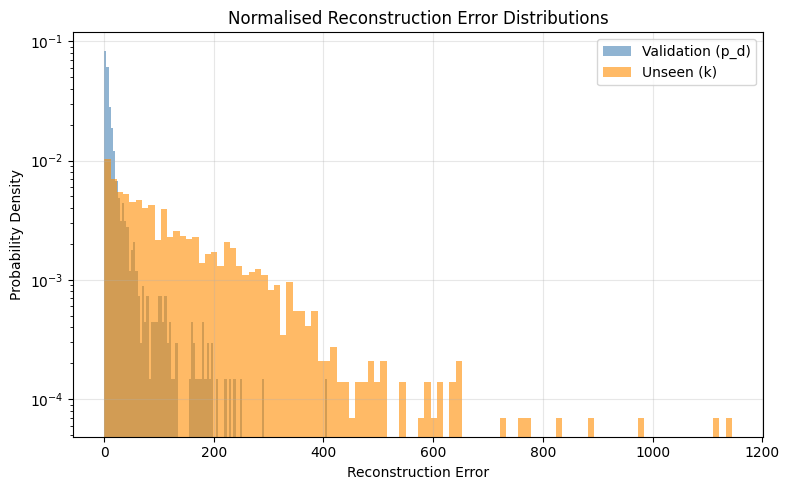

Validation mean RE: 16.1198673248 ± 30.3840599060
Unseen (d_d) mean RE: 129.5153045654 ± 133.9976654053


In [27]:
all_RE_val = np.concatenate(fold_REs)
all_RE_k  = np.concatenate(fold_REs_k)

plt.figure(figsize=(8, 5))
plt.hist(all_RE_val, bins=100, density=True, alpha=0.6, color='steelblue', label='Validation (p_d)')
plt.hist(all_RE_k, bins=100, density=True, alpha=0.6, color='darkorange', label='Unseen (k)')
plt.xlabel("Reconstruction Error")
plt.ylabel("Probability Density")
plt.title("Normalised Reconstruction Error Distributions")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Validation mean RE: {all_RE_val.mean():.10f} ± {all_RE_val.std():.10f}")
print(f"Unseen (d_d) mean RE: {all_RE_k.mean():.10f} ± {all_RE_k.std():.10f}")

Inference device: mps
recon_all.shape: (6699, 2, 64, 64)
latent_vectors.shape: (6699, 8)
RE_per_sample.shape: (6699,)


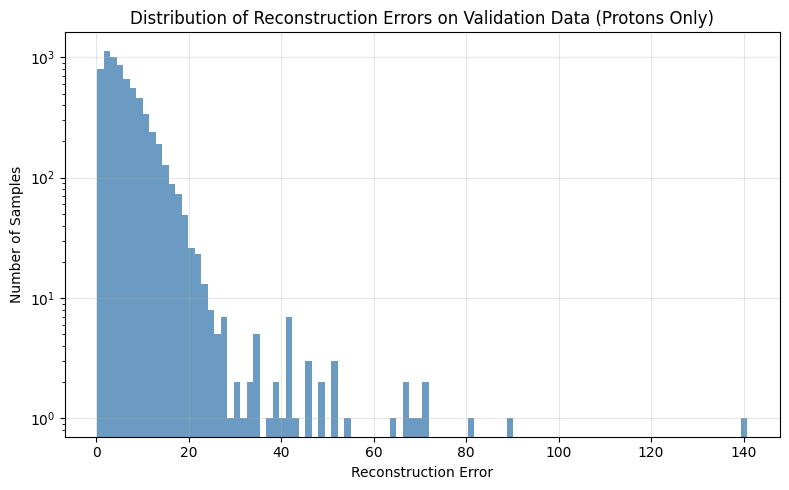

In [28]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_np = torch.stack([train_subset[i] for i in range(len(train_subset))]).cpu().numpy()        # (N, 2, H, W)
N, C, H, W = X_np.shape

batch_size = 8   
recon_all = np.empty((N, C, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, 2, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, 2, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent
        enc = model.encoder(xb)              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2, 3))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.tight_layout()
plt.show()

Inference device: mps
recon_all.shape: (1675, 2, 64, 64)
latent_vectors.shape: (1675, 8)
RE_per_sample.shape: (1675,)


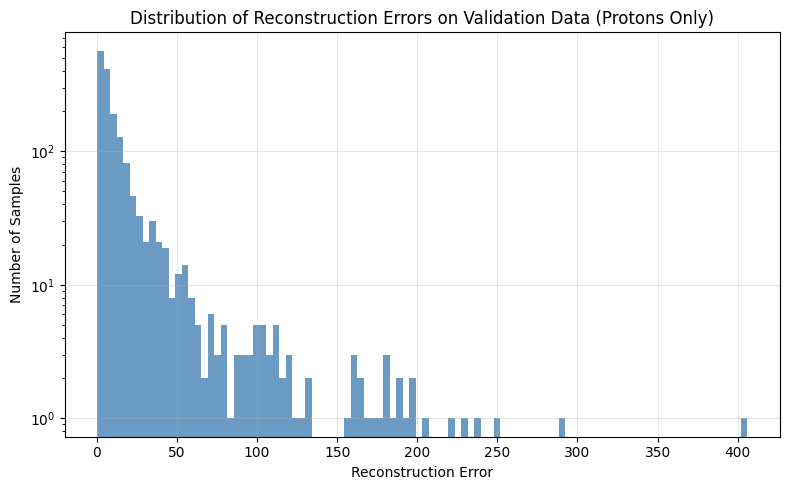

In [29]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_nval = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()        # (N, H, W)
N, C, H, W = X_nval.shape

batch_size = 8   
recon_all_val = np.empty((N, C, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors_val = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_nval[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all_val[i:j] = out_cpu

        # latent
        enc = model.encoder(xb)              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors_val[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all_val - X_nval) ** 2
RE_per_sample_val = mse_per_pixel.mean(axis=(1, 2, 3))        # (N,)

print("recon_all.shape:", recon_all_val.shape)
print("latent_vectors.shape:", latent_vectors_val.shape)
print("RE_per_sample.shape:", RE_per_sample_val.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample_val, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.tight_layout()
plt.show()

recon_all_k.shape: (1267, 2, 64, 64)
latent_vectors.shape: (1267, 8)
RE_per_sample_k.shape: (1267,)


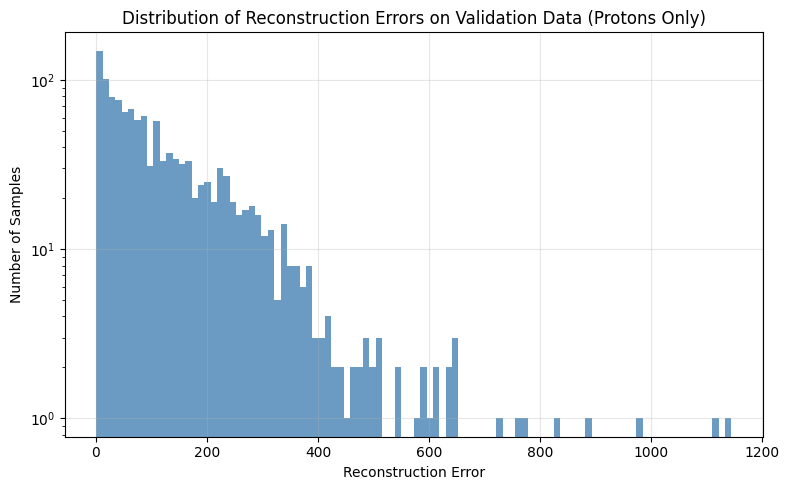

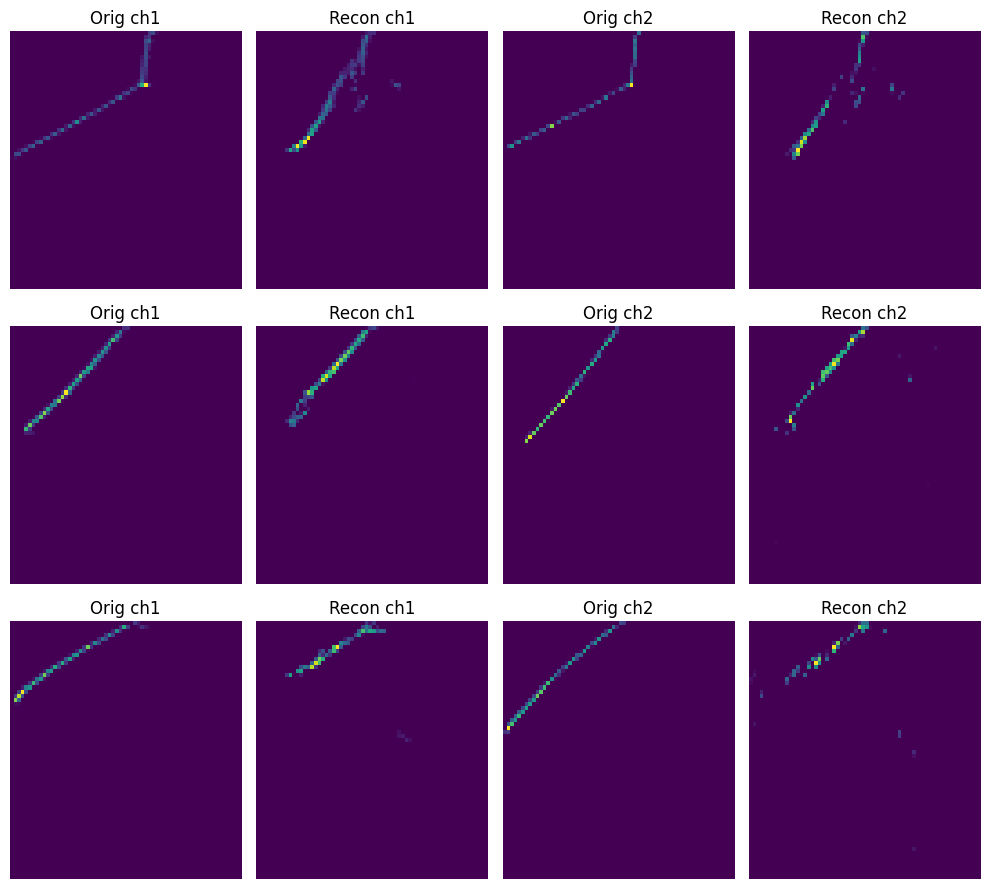

In [30]:
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.eval()
model.to(device_inf)

Xk_np = k.cpu().numpy() if torch.is_tensor(k) else np.array(k, dtype=np.float32)          # (N, H, W)
N, C, H, W = Xk_np.shape
batch_size = 8                           # lower if OOM on MPS

recon_all_k = np.empty((N, C, H, W), dtype=np.float32)
latent_dim = model.fc_enc.out_features
latent_vectors_k = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb = torch.tensor(Xk_np[i:j], dtype=torch.float32).to(device_inf)  # (b,H,W)

        out = model(xb)                         # (b,H,W)
        recon_all_k[i:j] = out.cpu().numpy()

        enc = model.encoder(xb)    # (b,C,h_enc,w_enc)
        z_flat = enc.flatten(1)                 # (b,flat_size)
        z = model.fc_enc(z_flat)                # (b,latent)
        latent_vectors_k[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

RE_per_sample_k = ((recon_all_k - Xk_np) ** 2).mean(axis=(1, 2, 3))

print("recon_all_k.shape:", recon_all_k.shape)
print("latent_vectors.shape:", latent_vectors_k.shape)
print("RE_per_sample_k.shape:", RE_per_sample_k.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample_k, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.tight_layout()
plt.show()

l = min(3, N)  # number of samples to show
fig, axs = plt.subplots(l, 4, figsize=(10, 3*l))  # 2 channels × (orig,recon)

for ii in range(l):
    for c in range(2):
        axs[ii, 2*c].imshow(Xk_np[ii, c], cmap='viridis', aspect='auto')
        axs[ii, 2*c].set_title(f"Orig ch{c+1}")
        axs[ii, 2*c].axis('off')

        axs[ii, 2*c+1].imshow(recon_all_k[ii, c], cmap='viridis', aspect='auto')
        axs[ii, 2*c+1].set_title(f"Recon ch{c+1}")
        axs[ii, 2*c+1].axis('off')

plt.tight_layout()
plt.show()


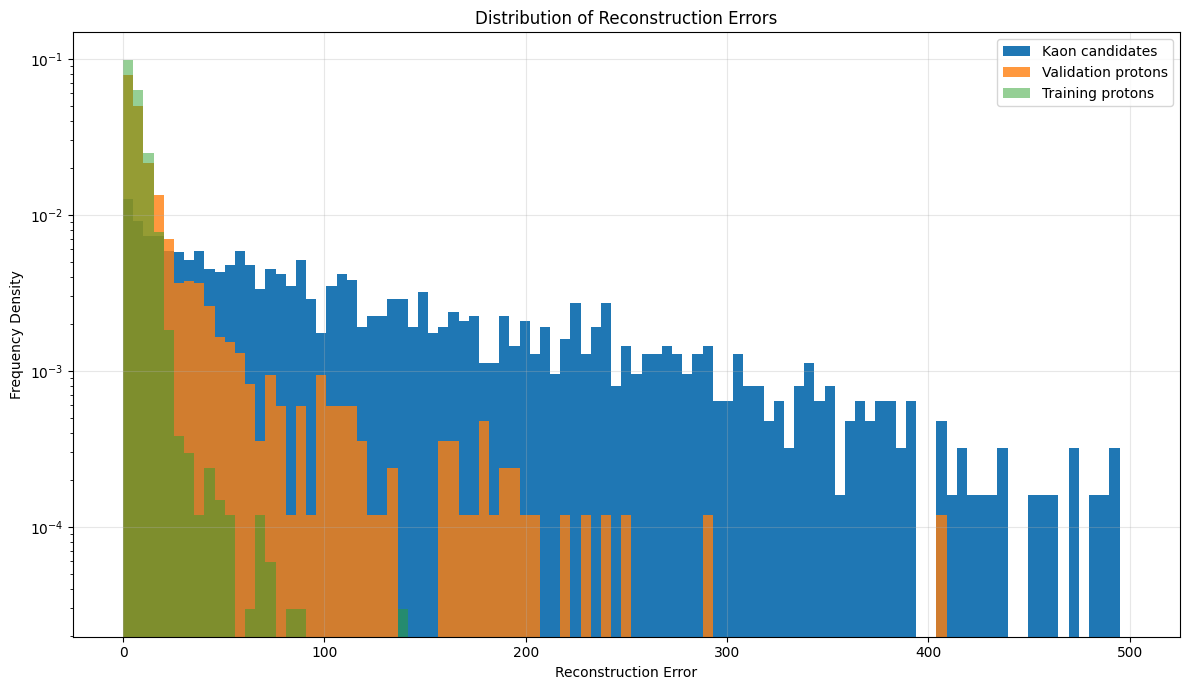

In [31]:
plt.figure(figsize=(12, 7))

bins = np.linspace(0, 500, 100)

plt.hist(RE_per_sample_k, bins=bins, alpha=1, label='Kaon candidates', density=True)
plt.hist(RE_per_sample_val, bins=bins, alpha=0.8, label='Validation protons', density=True)
plt.hist(RE_per_sample, bins=bins, alpha=0.5, label='Training protons', density=True)

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency Density")
plt.title("Distribution of Reconstruction Errors")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.legend()
plt.tight_layout()
plt.savefig('RE.png', dpi=1000)
plt.show()

In [32]:
# high_re_idx = np.where((RE_per_sample_k > 100))[0]
# print(f"Found {len(high_re_idx)} samples")

# k = min(3, len(high_re_idx))
# if k == 0:
#     print("No samples found in specified RE range.")
# else:
#     selected = np.random.choice(high_re_idx, size=k, replace=False)

#     # 4 columns: orig ch1 | recon ch1 | orig ch2 | recon ch2
#     fig, axs = plt.subplots(k, 4, figsize=(10, 3*k))

#     for ii in range(k):
#         idx = selected[ii]

#         # --- Channel 1 ---
#         axs[ii, 0].imshow(Xk_np[idx, 0], cmap='viridis', aspect='auto')
#         axs[ii, 0].set_title(f"Orig ch1\nidx={idx}, RE={RE_per_sample_k[idx]:.5f}")
#         axs[ii, 0].axis('off')

#         axs[ii, 1].imshow(recon_all[idx, 0], cmap='viridis', aspect='auto')
#         axs[ii, 1].set_title("Recon ch1")
#         axs[ii, 1].axis('off')

#         # --- Channel 2 ---
#         axs[ii, 2].imshow(Xk_np[idx, 1], cmap='viridis', aspect='auto')
#         axs[ii, 2].set_title("Orig ch2")
#         axs[ii, 2].axis('off')

#         axs[ii, 3].imshow(recon_all[idx, 1], cmap='viridis', aspect='auto')
#         axs[ii, 3].set_title("Recon ch2")
#         axs[ii, 3].axis('off')

#     plt.tight_layout()
#     plt.show()


In [33]:
from sklearn.manifold import TSNE

Z_all = np.concatenate([latent_vectors, latent_vectors_k, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_k)),         # 1 = kaons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

In [34]:
tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate=50,
    max_iter=2000,
    init='random',
    random_state=42
)
Z_2d = tsne.fit_transform(Z_all)

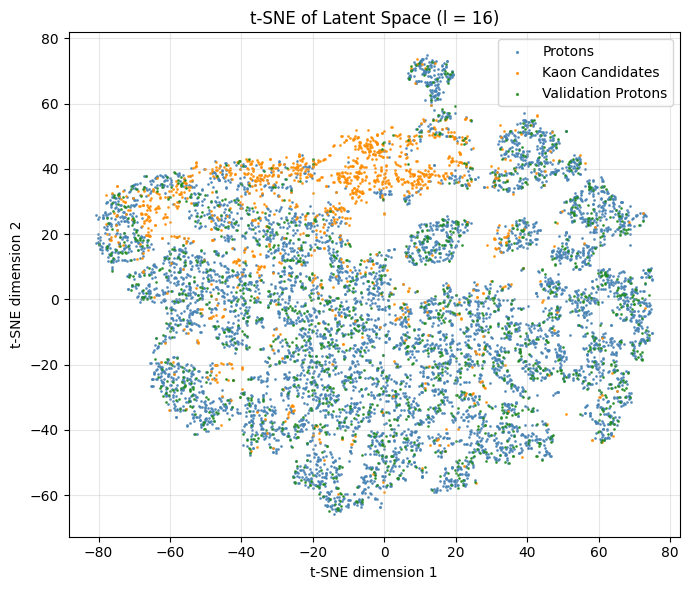

In [36]:
plt.figure(figsize=(7, 6))
colours = ['steelblue', 'darkorange', 'forestgreen']
labels_text = ['Protons', 'Kaon Candidates', 'Validation Protons']

for i, (colour, label_name) in enumerate(zip(colours, labels_text)):
    plt.scatter(Z_2d[labels == i, 0],
                Z_2d[labels == i, 1],
                color=colour,
                alpha=0.8,
                s=1,
                label=label_name)

plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(markerscale=1.3)
plt.title("t-SNE of Latent Space (l = 16)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

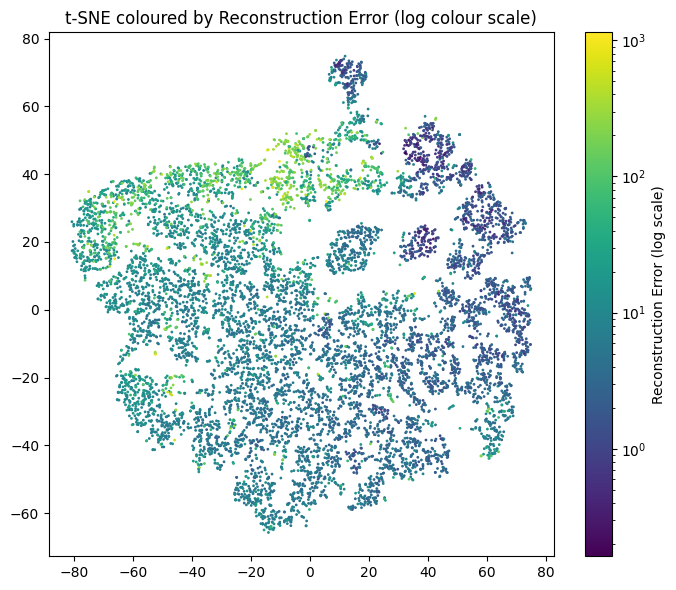

In [37]:
import matplotlib.colors as mcolors

Z_all = np.concatenate([latent_vectors, latent_vectors_k, latent_vectors_val])
RE_all = np.concatenate([RE_per_sample, RE_per_sample_k, RE_per_sample_val])

plt.figure(figsize=(7,6))
sc = plt.scatter(Z_2d[:, 0], Z_2d[:, 1],
                 c=RE_all,
                 cmap='viridis',
                 norm=mcolors.LogNorm(vmin=RE_all.min()+1e-8, vmax=RE_all.max()),
                 s=1)
plt.colorbar(sc, label='Reconstruction Error (log scale)')
plt.title("t-SNE coloured by Reconstruction Error (log colour scale)")
plt.tight_layout()
plt.show()

In [38]:
import umap
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
Z_umap = reducer.fit_transform(Z_all)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


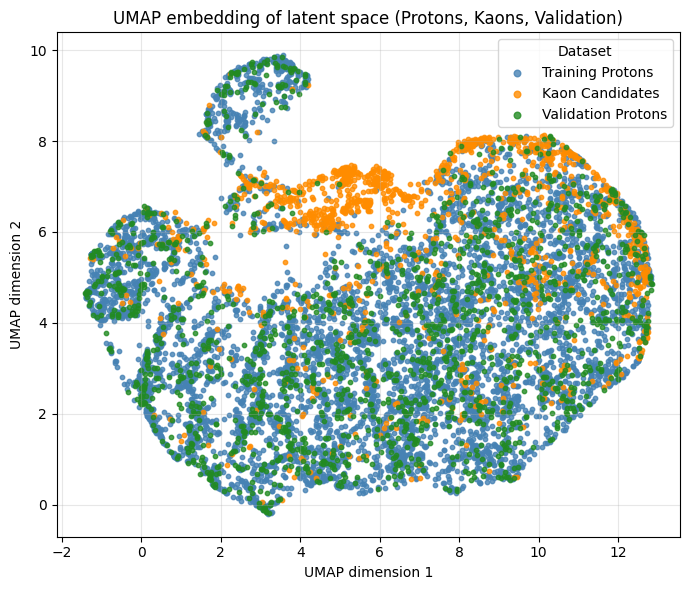

In [39]:
# labels: 0=Protons, 1=Kaons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Kaon Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)

plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("UMAP embedding of latent space (Protons, Kaons, Validation)")
plt.legend(title="Dataset", markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('UMAP.png', dpi=1000)
plt.show()

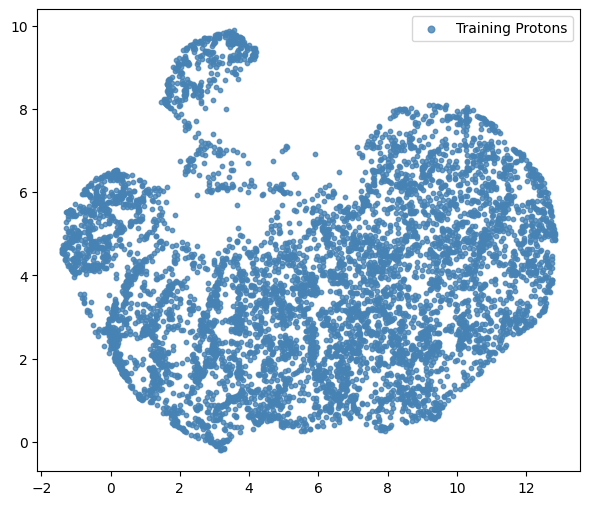

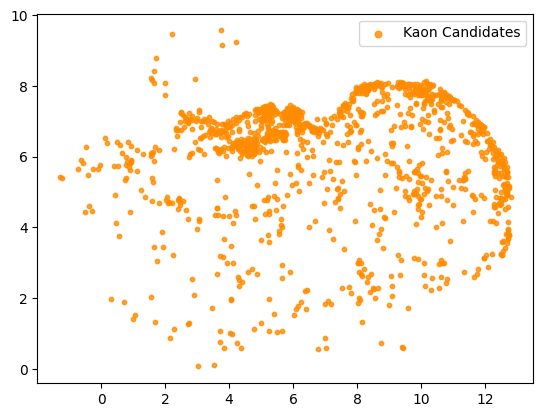

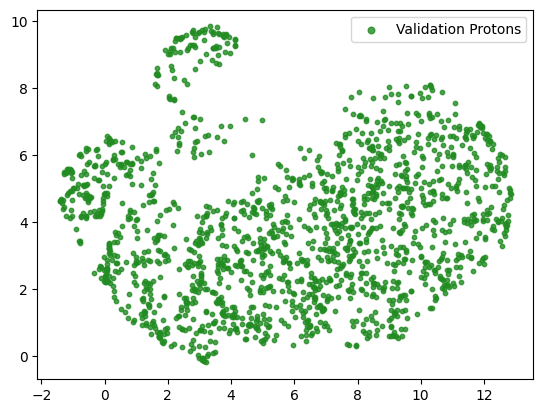

In [40]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Kaon Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)
    plt.legend(markerscale=1.5)
    # plt.xlim(-5, 14)
    # plt.ylim(0, 10)
    plt.show()

# plt.xlabel("UMAP dimension 1")
# plt.ylabel("UMAP dimension 2")
# plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
# plt.legend(title="Dataset", markerscale=1.5)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


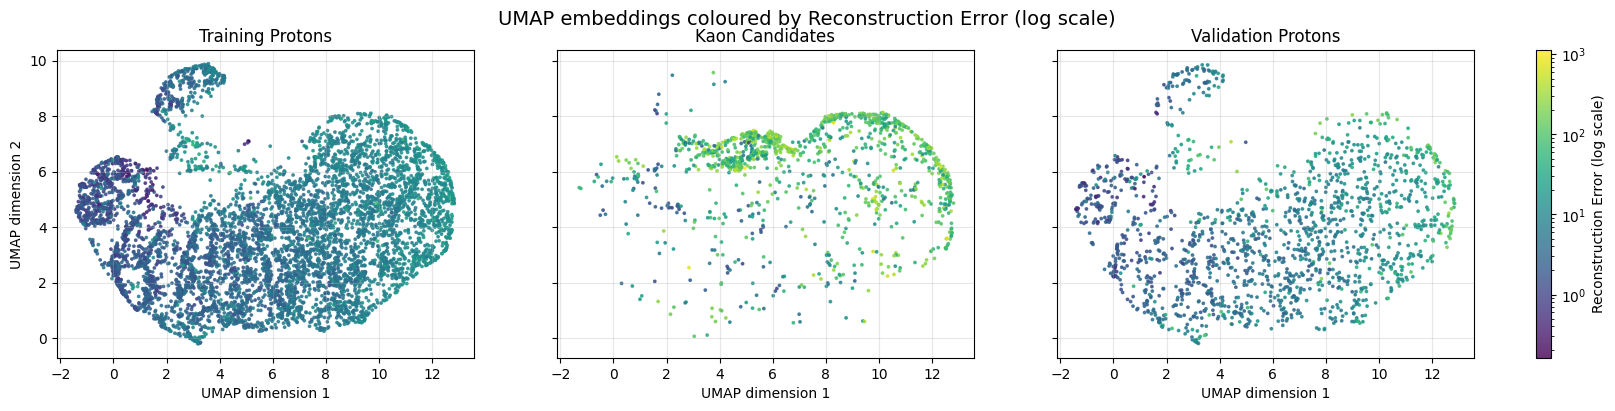

In [41]:
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Kaon Candidates', 'Validation Protons']

norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    m = (labels == i)
    sc = ax.scatter(
        Z_umap[m, 0],
        Z_umap[m, 1],
        c=RE_all[m],
        cmap=cmap,
        norm=norm,
        s=3,
        alpha=0.8
    )
    ax.set_title(names[i], fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    if i == 0:
        ax.set_ylabel("UMAP dimension 2")
    ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)

# plt.savefig('UMAPandRE.png', dpi=1000)
plt.show()


In [42]:
latent_vectors.shape, latent_vectors_val.shape, latent_vectors_k.shape

((6699, 8), (1675, 8), (1267, 8))

In [43]:
latent = np.concatenate([latent_vectors, latent_vectors_val])

Deuteron subset shape: (1267, 2)


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


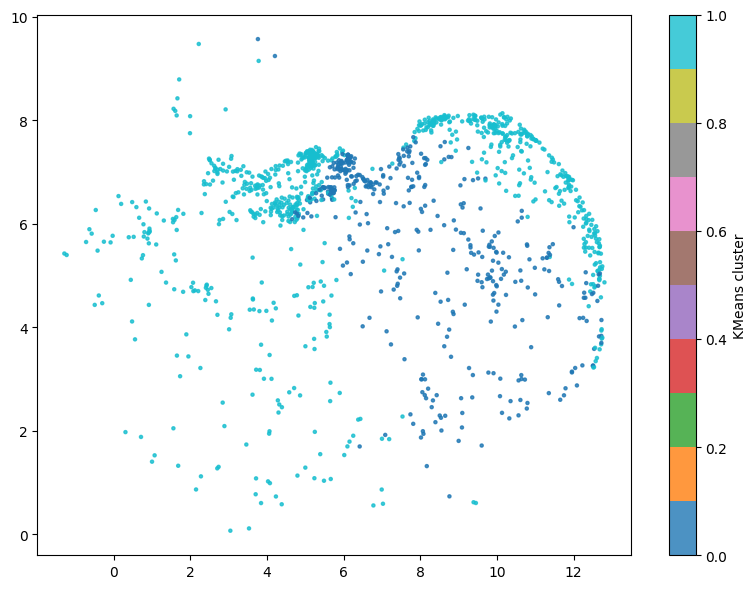

In [45]:
from sklearn.cluster import KMeans

Z_all = np.concatenate([latent_vectors, latent_vectors_k, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_k)),         # 1 = kaon
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

mask = (labels == 1)
Z_d = Z_all[mask]          # latent vectors
E_d = Z_umap[mask]      # 3D UMAP coordinates

print(f"Deuteron subset shape: {E_d.shape}")

kmeans = KMeans(n_clusters=2, random_state=42) #6
labels_km = kmeans.fit_predict(Z_d)

fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                c=labels_km, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
# plt.savefig('Kmeans.png', dpi=1000)
plt.show()


In [46]:
p_m = col[col['particle_type'] == 'proton']['beamline_mass'].values
k_m = col[col['particle_type'] == 'kaon']['beamline_mass'].values

k_l = col[col['particle_type'] == 'kaon']['height'].values
k_p = col[col['particle_type'] == 'kaon']['p'].values

labels = labels_km

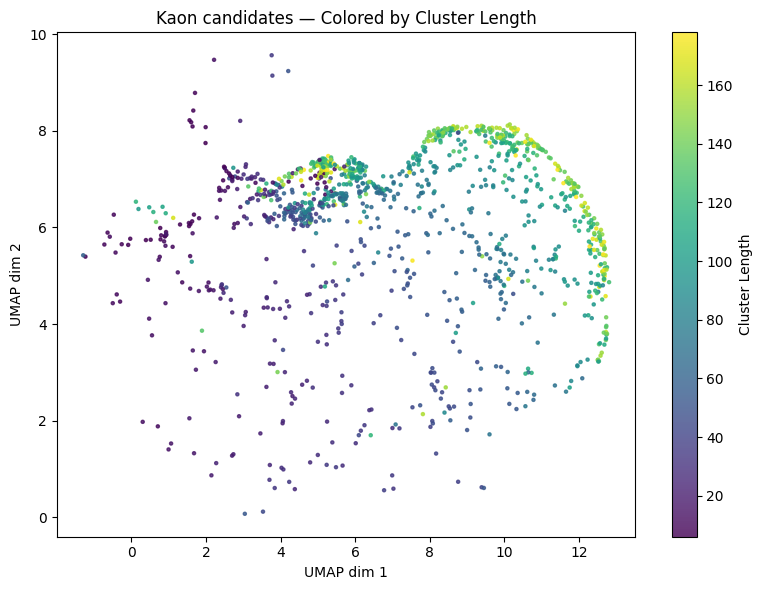

In [47]:
fig = plt.figure(figsize=(8, 6))

# Scatter plot colored by cluster length
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                 c=k_l, cmap='viridis', s=5, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Length")

plt.title("Kaon candidates — Colored by Cluster Length")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
# plt.savefig('length.png', dpi=1000)
plt.show()

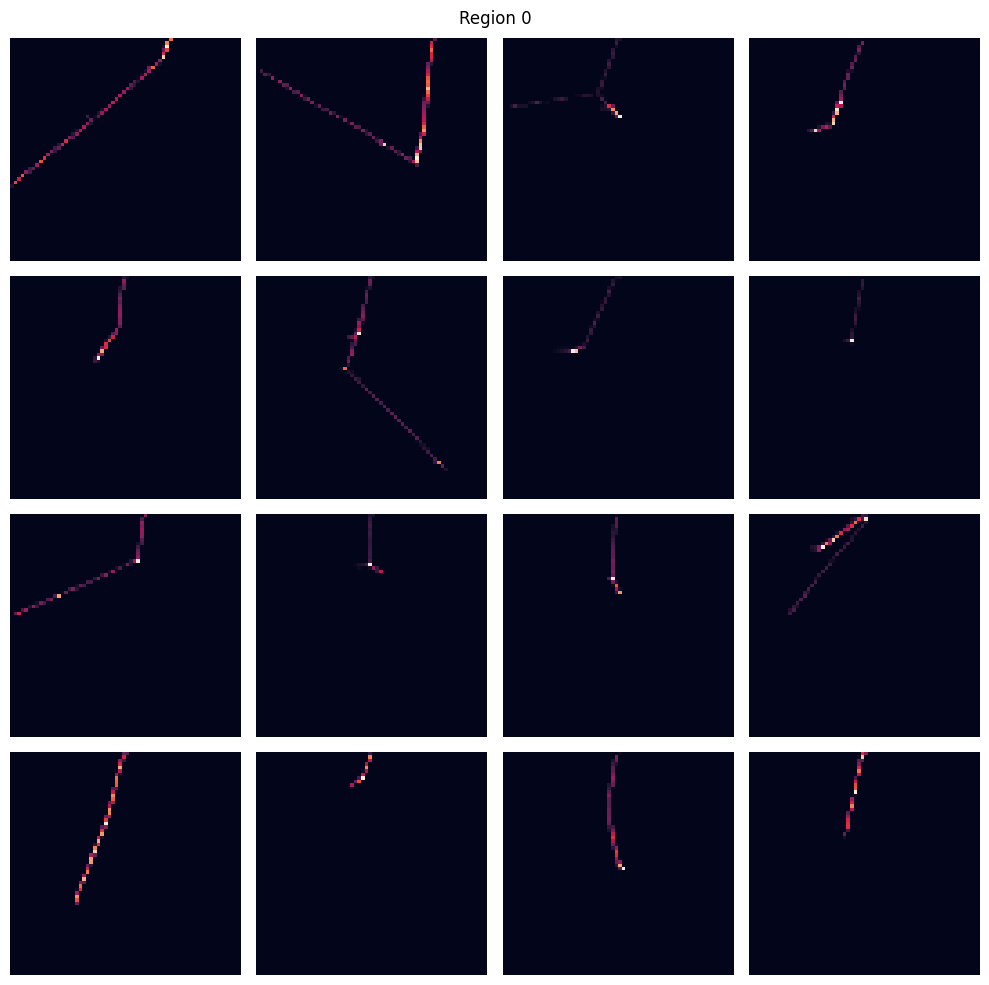

In [48]:
num_images = 16  # Number of images to display
grid_size = int(np.ceil(np.sqrt(num_images)))  # Grid dimensions (grid_size x grid_size)

# Filter the original images for the selected cluster
cluster_id = 0 # Change this to the desired cluster ID
cluster_mask = (labels_km == cluster_id)
cluster_indices = np.where(cluster_mask)[0]

# Randomly select up to `num_images` images from the cluster
if len(cluster_indices) > num_images:
    selected_indices = np.random.choice(cluster_indices, size=num_images, replace=False)
else:
    selected_indices = cluster_indices

selected_images = k[selected_indices]

fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i, 1], ax=ax, cbar=False, xticklabels=False, yticklabels=False)
    else:
        ax.axis('off')  # Turn off unused subplots

fig.suptitle(f'Region {cluster_id}')
plt.tight_layout()
plt.show()

In [49]:
RE_all = np.concatenate([RE_per_sample, RE_per_sample_k, RE_per_sample_val])

RE_X = np.concatenate([RE_per_sample, RE_per_sample_val])
RE_Y = RE_per_sample_k

Density map

In [50]:
from sklearn.neighbors import NearestNeighbors
from scipy.special import gammaln

In [51]:
k.shape

torch.Size([1267, 2, 64, 64])

In [52]:
latent = np.concatenate([latent_vectors, latent_vectors_val])

X = np.asarray(latent)              # reference = protons
Y = np.asarray(latent_vectors_k)            # query = kaons

N, d = X.shape

n = 20

kNN = NearestNeighbors(n_neighbors=n, algorithm='auto')
kNN.fit(X)

distancesX, _ = kNN.kneighbors(X)
rkX = distancesX[:, -1]

log_Vd = (d / 2) * np.log(np.pi) - gammaln(d / 2 + 1)                  # volume of ball (log for numerical stability) - standard equation for d dimension ball

log_pX = np.log(n) - np.log(N) - log_Vd - d * np.log(rkX + 1e-12)

distances, _ = kNN.kneighbors(Y)
rk = distances[:, -1]

log_Vd = (d / 2) * np.log(np.pi) - gammaln(d / 2 + 1)                  # volume of ball (log for numerical stability) - standard equation for d dimension ball

log_pY = np.log(n) - np.log(N) - log_Vd - d * np.log(rk + 1e-12)

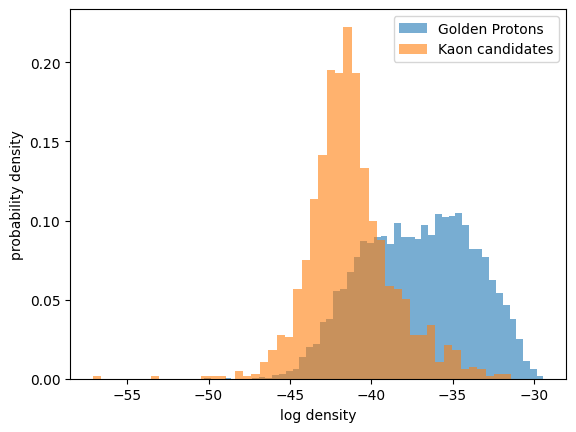

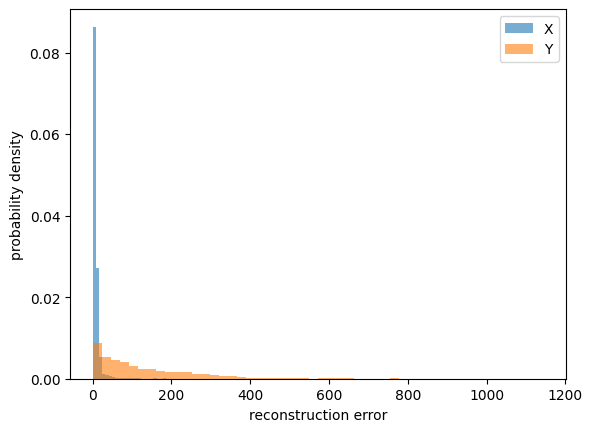

In [53]:
log_pX = np.asarray(log_pX); log_pY = np.asarray(log_pY)
RE_X   = np.asarray(RE_X);   RE_Y   = np.asarray(RE_Y)

# log density
plt.figure()
plt.hist(log_pX, bins=50, density=True, alpha=0.6, label="Golden Protons")
plt.hist(log_pY, bins=50, density=True, alpha=0.6, label="Kaon candidates")
plt.xlabel("log density")
plt.ylabel("probability density")
plt.legend()
plt.show()

# reconstruction error
plt.figure()
plt.hist(RE_X, bins=50, density=True, alpha=0.6, label="X")
plt.hist(RE_Y, bins=50, density=True, alpha=0.6, label="Y")
plt.xlabel("reconstruction error")
plt.ylabel("probability density")
plt.legend()
plt.show()

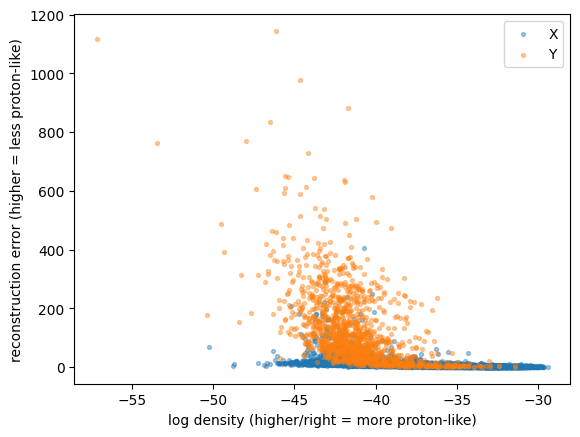

In [54]:
plt.figure()
plt.scatter(log_pX, RE_X, s=8, alpha=0.4, label="X")
plt.scatter(log_pY, RE_Y, s=8, alpha=0.4, label="Y")
plt.xlabel("log density (higher/right = more proton-like)")
plt.ylabel("reconstruction error (higher = less proton-like)")
plt.legend()
plt.show()

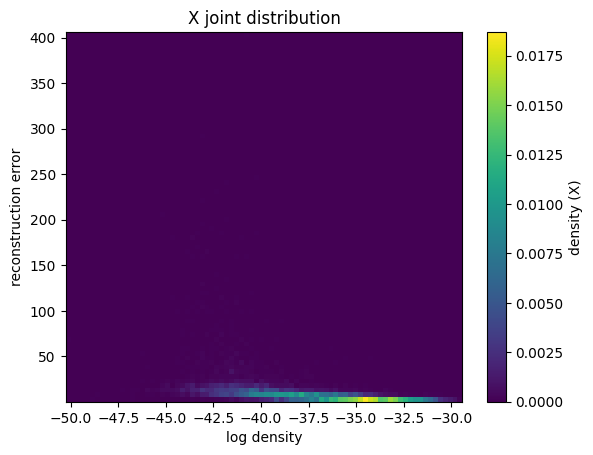

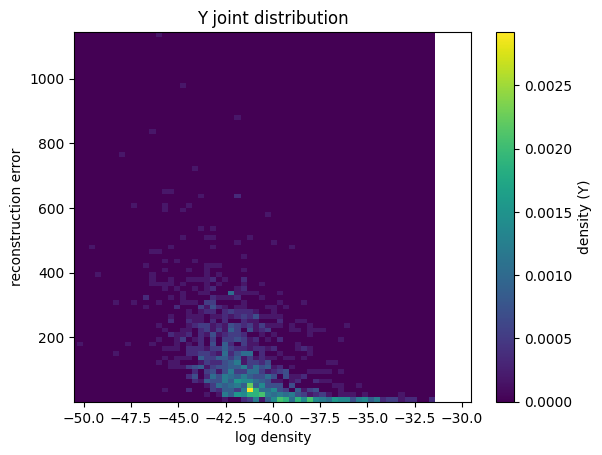

In [58]:
plt.figure()
plt.hist2d(log_pX, RE_X, bins=80, density=True)
plt.xlabel("log density")
plt.ylabel("reconstruction error")
plt.colorbar(label="density (X)")
plt.title("X joint distribution")
# plt.xlim(-48, -28)
plt.show()

plt.figure()
plt.hist2d(log_pY, RE_Y, bins=80, density=True)
plt.xlabel("log density")
plt.ylabel("reconstruction error")
plt.colorbar(label="density (Y)")
plt.title("Y joint distribution")
plt.xlim(-50.5, -29.5)
plt.show()

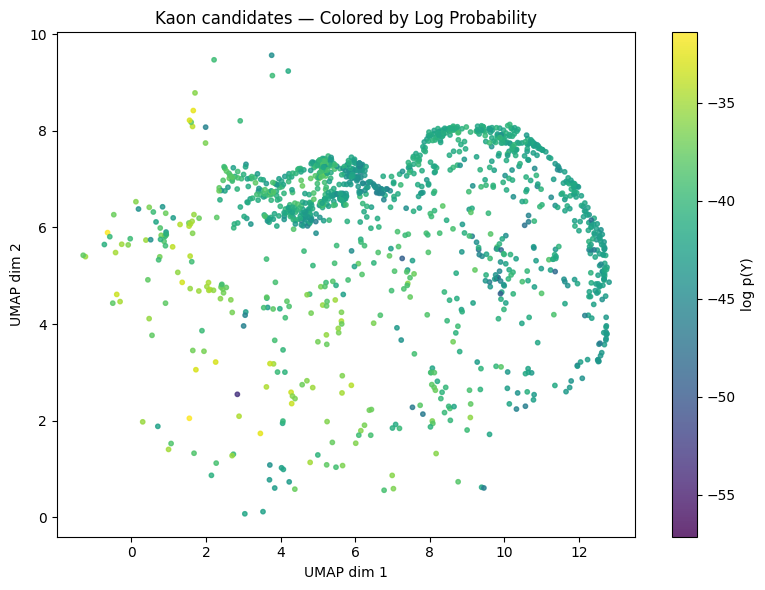

In [59]:
fig = plt.figure(figsize=(8, 6))

# Scatter plot colored by cluster length
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                 c=log_pY, cmap='viridis', s=10, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("log p(Y)")

plt.title("Kaon candidates — Colored by Log Probability")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
# plt.savefig('length.png', dpi=1000)
plt.show()

In [75]:
len(indices[0])

1161

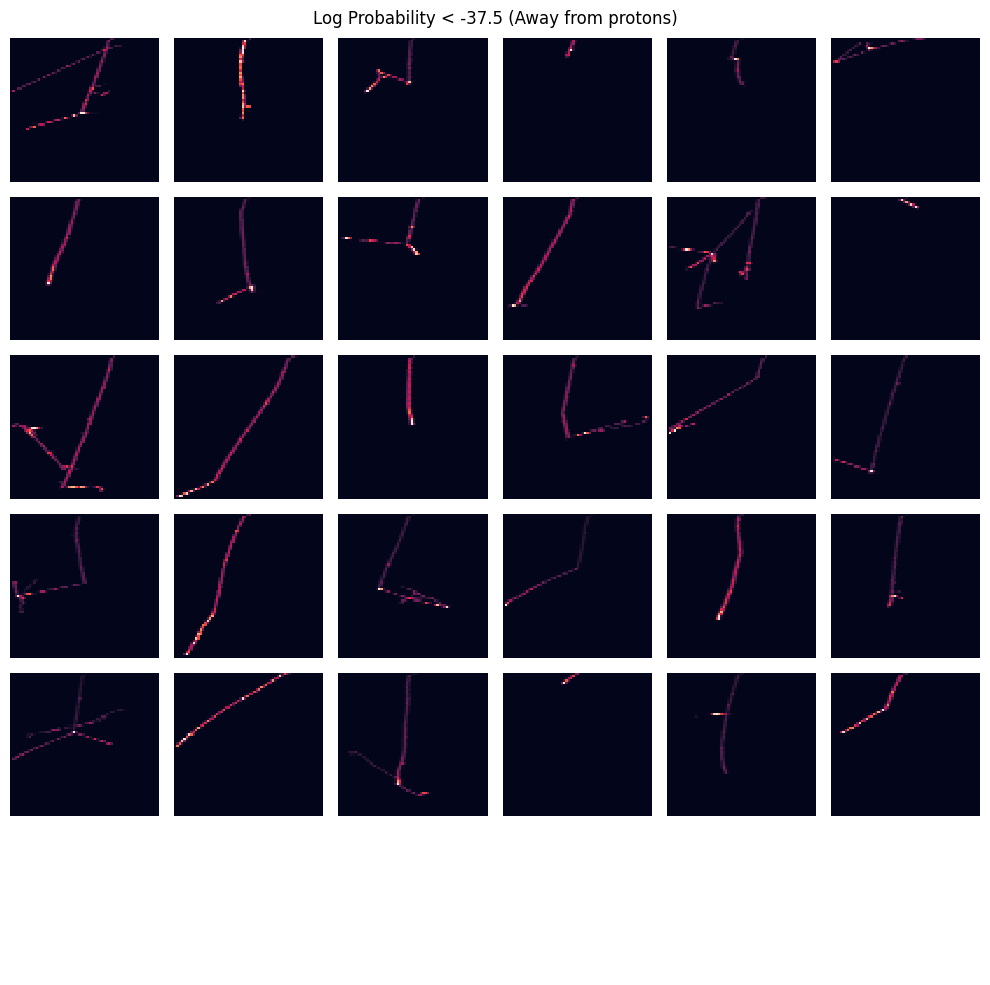

In [93]:
indices = np.where(log_pY < -37.5)

num_images = 30  
grid_size = int(np.ceil(np.sqrt(num_images)))  

if len(indices[0]) > num_images:
    selected_indices = np.random.choice(indices[0], size=num_images, replace=False)
else:
    selected_indices = indices

selected_images = k[selected_indices]

fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i, 0], ax=ax, cbar=False, xticklabels=False, yticklabels=False)
    else:
        ax.axis('off')  

fig.suptitle(f'Log Probability < -37.5 (Away from protons)')
plt.tight_layout()
plt.show()

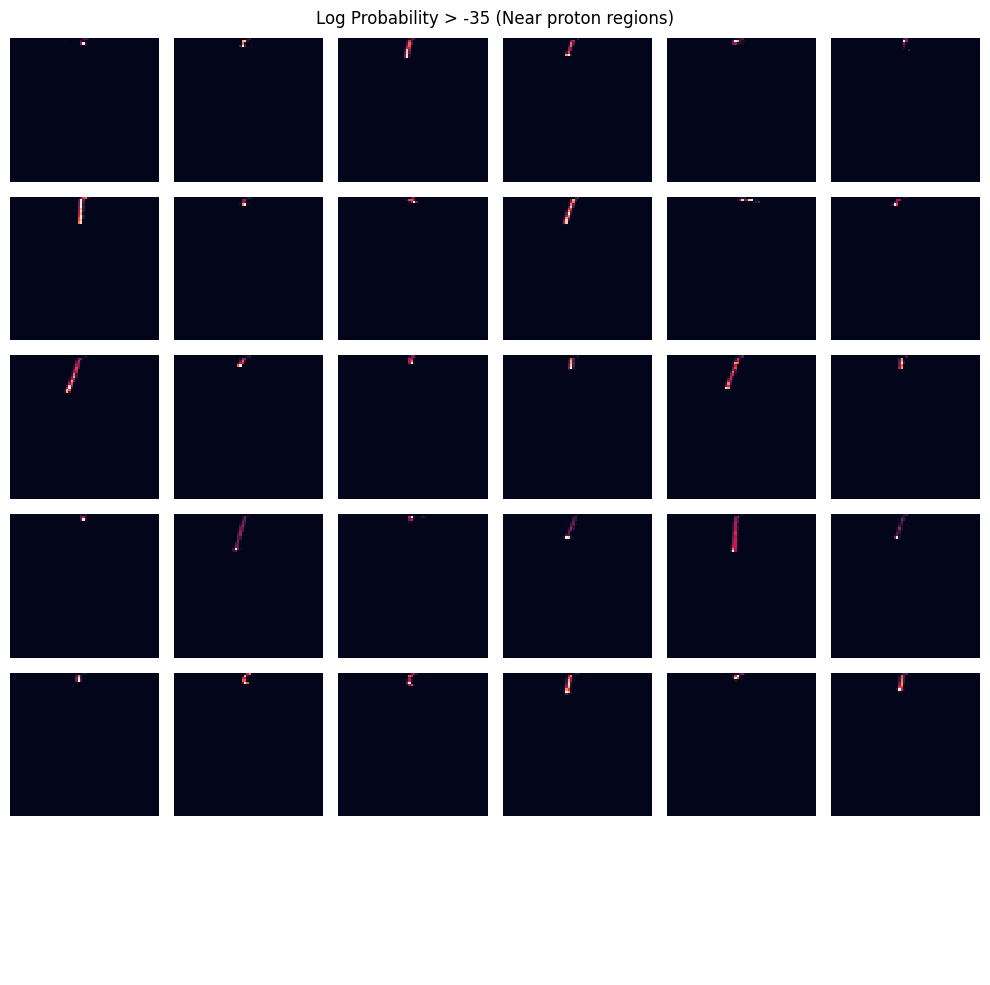

In [ ]:
indices = np.where(log_pY > -37.5)

num_images = 30  
grid_size = int(np.ceil(np.sqrt(num_images)))  

if len(indices[0]) > num_images:
    selected_indices = np.random.choice(indices[0], size=num_images, replace=False)
else:
    selected_indices = indices

selected_images = k[selected_indices]

fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i, 0], ax=ax, cbar=False, xticklabels=False, yticklabels=False)
    else:
        ax.axis('off')  

fig.suptitle(f'Log Probability > -37.5 (Near proton regions)')
plt.tight_layout()
plt.show()

feature: Angle

In [99]:
images = []

for idx, row in col.iterrows():
    padded = pad_image(
        row['image_intensity'])
    images.append(padded)

ind_images = []

for idx, row in ind.iterrows():
    padded = pad_image(
        row['image_intensity'])
    ind_images.append(padded)

In [100]:
heights = col['height'].values
starts = np.array([np.argmax(img[0,:]) for img in images])
ends = np.array([np.argmax(img[h-1, :]) for img, h in zip(images, heights)])

thetas = np.arctan((starts - ends) / heights)
thetas = np.degrees(thetas)

col['thetas'] = thetas

heights = ind['height'].values
starts = np.array([np.argmax(img[0,:]) for img in images])
ends = np.array([np.argmax(img[h-1, :]) for img, h in zip(images, heights)])

thetas = np.arctan((starts - ends) / heights)
thetas = np.degrees(thetas)

ind['thetas'] = thetas

(array([ 44.,  40.,  21.,  28.,  17.,  14.,  12.,  12.,  18.,   9.,  11.,
         17.,  18.,  24.,  24.,  40.,  36.,  65., 112., 167., 279., 259.]),
 array([-89.43908022, -81.32616027, -73.21324031, -65.10032036,
        -56.98740041, -48.87448045, -40.7615605 , -32.64864055,
        -24.5357206 , -16.42280064,  -8.30988069,  -0.19696074,
          7.91595922,  16.02887917,  24.14179912,  32.25471908,
         40.36763903,  48.48055898,  56.59347893,  64.70639889,
         72.81931884,  80.93223879,  89.04515875]),
 <BarContainer object of 22 artists>)

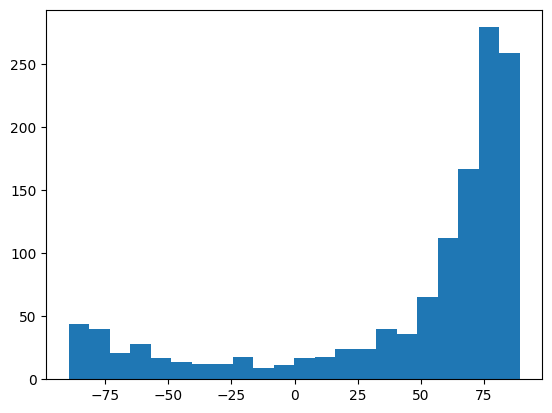

In [102]:
plt.hist(col[col['particle_type'] == 'kaon']['thetas'], bins='auto')

(array([  4.,   7.,  10.,  10.,   2.,   3.,   8.,   0.,   4.,   2.,   5.,
          2.,   8.,   6.,   4.,   5.,   5.,   2.,   3.,   2.,   3.,   2.,
          1.,   5.,   0.,   1.,   6.,   5.,   3.,   2.,   2.,   6.,   1.,
          7.,   1.,   3.,   3.,   4.,   3.,   5.,   0.,   2.,   1.,   4.,
          5.,   3.,   6.,   5.,   1.,  10.,   1.,   3.,   0.,   2.,   3.,
          5.,   8.,   7.,   8.,   1.,   1.,   3.,   5.,  11.,   4.,   2.,
          9.,   4.,   4.,   4.,  10.,   4.,   7.,   5.,   3.,   6.,   8.,
         10.,   9.,   3.,   5.,   4.,   6.,   8.,   8.,   7.,  14.,   6.,
          9.,  13.,  10.,   9.,  17.,  17.,  13.,  10.,  15.,  20.,  13.,
         18.,  23.,  20.,  27.,  27.,  21.,  25.,  31.,  32.,  23.,  44.,
         40.,  49.,  50.,  54.,  48.,  72.,  76.,  85.,  87., 112., 148.,
        153., 202., 197., 239., 252., 322., 357., 401., 460., 549., 558.,
        558., 607., 527., 419., 354., 277., 158.,  70.,  44.,  12.]),
 array([-86.79051368, -85.55459033, -84.31

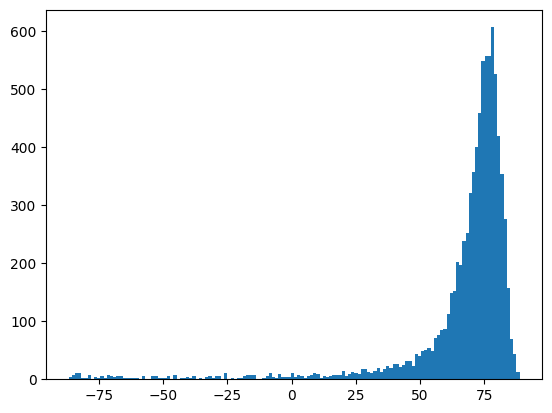

In [103]:
plt.hist(col[col['particle_type'] == 'proton']['thetas'], bins='auto')

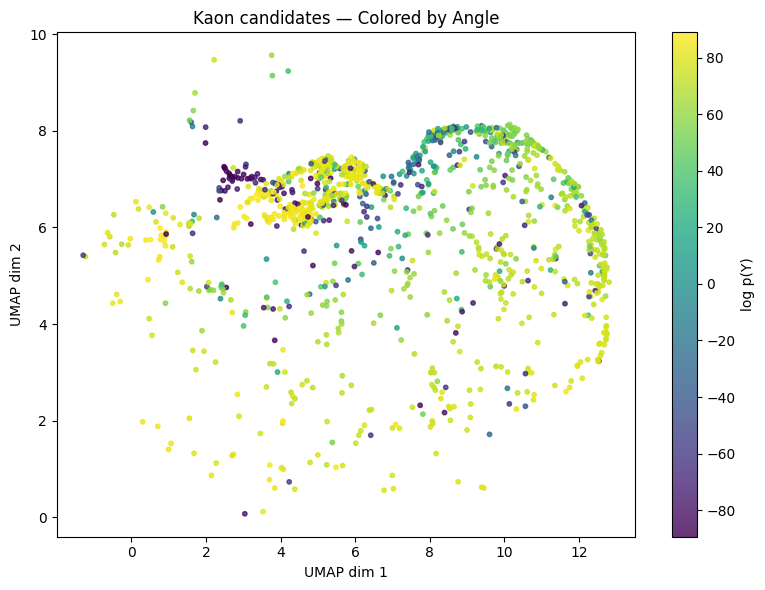

In [105]:
fig = plt.figure(figsize=(8, 6))

# Scatter plot colored by cluster length
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                 c=col[col['particle_type'] == 'kaon']['thetas'], cmap='viridis', s=10, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("log p(Y)")

plt.title("Kaon candidates — Colored by Angle")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
# plt.savefig('length.png', dpi=1000)
plt.show()